# Import dataset

In [23]:
import sys
print(sys.executable)

/Users/nicole/data-training/.venv/bin/python


In [24]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns 
import numpy as np
import json

In [25]:
# read bigquery data into pandas dataframe
import pandas as pd

df = pd.read_gbq(
    """
    SELECT  *
    FROM `jr-data-training.cafe.cafe-sales`
    --- LIMIT 10
  """,
    project_id="jr-data-training",
    location="australia-southeast1",
)

/var/folders/03/kg6152lx62g3z5rhmtm47_c80000gn/T/ipykernel_45184/1097260367.py:4: FutureWarning:

read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq



# Evaluation of the average revenue per customer


Using RFM analysis to divide customers into different segments:

- Recency: How recently has the customer made a transaction with us
- Frequency: How frequent is the customer in ordering/buying some product from us
- Monetary: How much does the customer spend on purchasing products from us.

My tutorial link: 

[Link](https://medium.com/@melodyyip_/rfm-customer-segmentation-using-python-1a1865c6e7cb)

[Github code](https://melodyyip.github.io/RFM-UCI-onlineStore/)

In [26]:
# Create a RFM table
rfm_df = df.groupby('customer_id').agg(
    Recency=('date_created', lambda x: (df['date_created'].max() - x.max()).days),
    Frequency=('date_created', 'count'),
    Monetary=('total', 'sum')
).reset_index()

## RFM distributions

In [27]:
fig = px.histogram(rfm_df, x='Recency', title='Recency Distribution', nbins=20, histnorm='probability density')
fig.show()

fig = px.histogram(rfm_df, x='Frequency', title='Frequency Distribution', nbins=20, histnorm='probability density')
fig.show()

fig = px.histogram(rfm_df, x='Monetary', title='Monetary Value Distribution', nbins=20, histnorm='probability density')
fig.show()

Based on the graph above, data transformation is needed as all of them are right-skewed form. 

### Data transformation

#### Initial transformation test

In [40]:
from scipy import stats

'''
 Function for experimenting different transformation methods:

    - log transformation
    - square root transformation
    - box-cox transformation Note
    
'''

def analyze_skewness(x):

    fig, ax = plt.subplots(2, 2, figsize=(6, 6))

    # To ensure the data is positive / non-zero
    adjust_x = np.clip(rfm_df[x], 1e-6, None)

    sns.histplot(adjust_x, ax=ax[0, 0], kde=True)
    sns.histplot(np.log(adjust_x), ax=ax[0, 1], kde=True)
    sns.histplot(np.sqrt(adjust_x), ax=ax[1, 0], kde=True)
    sns.histplot(stats.boxcox(adjust_x)[0], ax=ax[1, 1], kde=True)

    plt.tight_layout()
    plt.show()

    skew_coe = adjust_x.skew().round(2)

    print('Log Transform : The skew coefficient of', skew_coe, 'to', np.log(skew_coe))
    print('Square Root Transform : The skew coefficient of', skew_coe, 'to', np.sqrt(skew_coe))
    print('Box-Cox Transform : The skew coefficient of', skew_coe, 'to', pd.Series(stats.boxcox(adjust_x)[0]).skew().round(2))


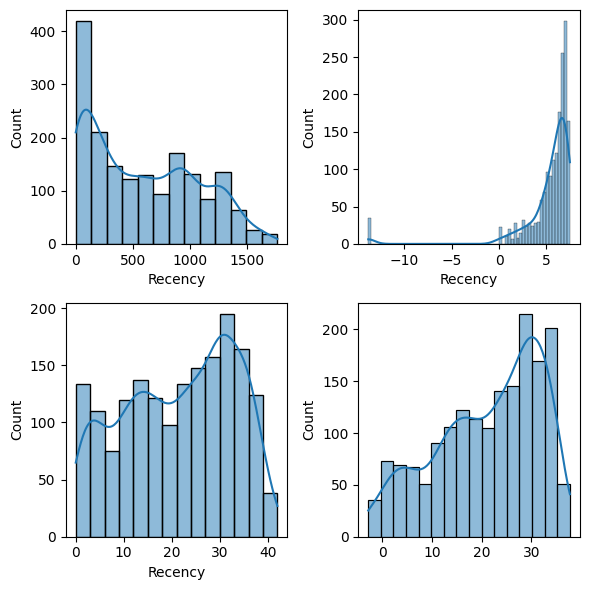

Log Transform : The skew coefficient of 0.4 to -0.916290731874155
Square Root Transform : The skew coefficient of 0.4 to 0.6324555320336759
Box-Cox Transform : The skew coefficient of 0.4 to -0.54


In [37]:
analyze_skewness('Recency')

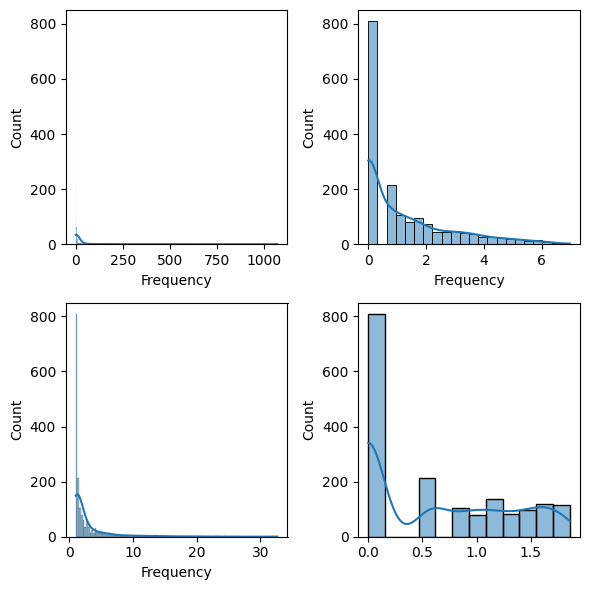

Log Transform : The skew coefficient of 7.47 to 2.010894999144726
Square Root Transform : The skew coefficient of 7.47 to 2.7331300737432898
Box-Cox Transform : The skew coefficient of 7.47 to 0.44


In [38]:
analyze_skewness('Frequency')

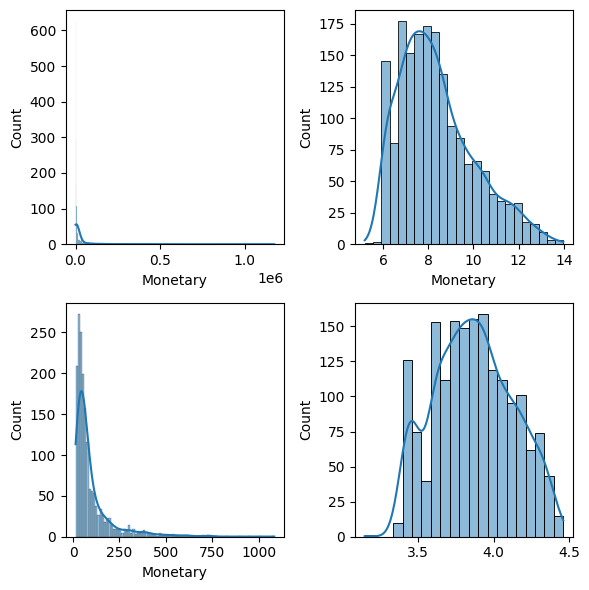

Log Transform : The skew coefficient of 7.35 to 1.9947003132247452
Square Root Transform : The skew coefficient of 7.35 to 2.711088342345192
Box-Cox Transform : The skew coefficient of 7.35 to 0.1


In [39]:
analyze_skewness('Monetary')

The graphs and calculation result showed that the variables with **box-cox transformation** shows a more symmetrical form rather than the other transformations.

#### Adjust the data with Box-Cox Transform

In [45]:
rfm_df["R_transformed"] = pd.Series(np.cbrt(rfm_df['Recency'])).values
rfm_df["F_transformed"] = stats.boxcox(rfm_df['Frequency'])[0]
rfm_df["M_transformed"] = stats.boxcox(rfm_df['Monetary'])[0]

## Normalizing the rank of the customers based upon their recency, frequency, and monetary score

In [ ]:
rfm_df['R_rank'] = rfm_df['Recency'].rank(ascending=False)
rfm_df['F_rank'] = rfm_df['Frequency'].rank(ascending=True)
rfm_df['M_rank'] = rfm_df['Monetary'].rank(ascending=True)
 
# Normalizing the rank of the customers
rfm_df['R_rank_norm'] = (rfm_df['R_rank']/rfm_df['R_rank'].max())*100
rfm_df['F_rank_norm'] = (rfm_df['F_rank']/rfm_df['F_rank'].max())*100
rfm_df['M_rank_norm'] = (rfm_df['F_rank']/rfm_df['M_rank'].max())*100
 
rfm_df.drop(columns=['R_rank', 'F_rank', 'M_rank'], inplace=True)
 
rfm_df.head()